# Classification de texte avec des RNNs

Dans cette démonstration, nous allons utiliser des RNNs pour retrouver l'auteur d'un texte.

Le corpus utilisé est tiré d'œuvres littéraires classiques de littérature anglophone : 9 auteurs, 2 livres par auteurs avec un fichier par chapitre.

## Téléchargement des données depuis un répo git

In [ ]:
!git clone https://github.com/nzmonzmp/dataset-9classical-author.git

fatal: destination path 'dataset-9classical-author' already exists and is not an empty directory.


## Téléchargement du modèle spacy pour l'anglais

In [ ]:
spacy_updated = !pip freeze | grep spacy==3
if not spacy_updated:
  !pip install 'spacy >= 3, < 4'
!python -m spacy download en_core_web_sm

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 12.8 MB 314 kB/s 
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


## Import de TensorFlow et des autres librairies nécessaires

In [ ]:
import re
import typing

import matplotlib.pyplot as plt
import numpy
import pathlib
import seaborn
import sklearn.model_selection
import sklearn.preprocessing
import spacy
import tensorflow as tf
import tqdm.notebook

## Prétraitements

- Chaque phrase est un exemple
- Sont remplacés par leur type (avec la première lettre triplée pour créer de nouveaux « mots ») tout mot (ou groupe de mots) étant une entité nommée

In [ ]:
nlp = spacy.load(
    "en_core_web_sm",
    exclude=("tok2vec", "tagger", "parser", "attribute_ruler", "lemmatizer"))
nlp.enable_pipe("senter")


def replace_ners(tokens: typing.Iterable[spacy.tokens.Token]
                 ) -> typing.Iterator[str]:
  result = []
  for token in tokens:
    if token.ent_iob_ == "O":
      yield token.text
    elif token.ent_iob_ == "B":
      prefix = token.ent_type_[0]
      yield f"{prefix}{prefix}{token.ent_type_}"


def get_data(directory: pathlib.Path,
             ) -> typing.Tuple[typing.List[str], typing.List[str]]:
  texts = []
  authors = []
  paths = list(directory.glob("*/*/*.txt"))
  contents = (p.read_text(encoding="utf8").replace("\n", " ") for p in paths)
  for path, doc in tqdm.notebook.tqdm(zip(paths, nlp.pipe(contents,
                                                          n_process=-1)),
                                      total=len(paths)):

    author = path.parent.parent.name
    for sentence in doc.sents:
      authors.append(author)
      texts.append(" ".join(replace_ners(sentence)))

  return texts, authors


texts, authors = get_data(pathlib.Path("dataset-9classical-author"))

label_encoder = sklearn.preprocessing.LabelEncoder()
y = label_encoder.fit_transform(authors)

print("Nombre de textes et forme de y :", len(texts), y.shape)

X_train_raw, X_test_raw, y_train, y_test = \
    sklearn.model_selection.train_test_split(texts, y, test_size=0.3)

  0%|          | 0/1214 [00:00<?, ?it/s]

Nombre de textes et forme de y : 75158 (75158,)


In [ ]:
print(len(X_train_raw), y_train.shape)

52610 (52610,)


## Préparation des données en séquences



### Préparation du dictionnaire et des séquences

À l'aide de l'outil [`tf.keras.preprocessing.text.Tokenizer`](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/text/Tokenizer), nous allons :
- Constituer un dictionnaire sur le corpus `X_train_raw`
- Chercher la taille du vocabulaire
- Chercher la taille maximale en nombre de mots d'une phrase ?

In [ ]:
tokenizer = tf.keras.preprocessing.text.Tokenizer()
tokenizer.fit_on_texts(X_train_raw)

In [ ]:
vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(s.split()) for s in X_train_raw)
print(f"Taille du vocabulaire : {vocab_size}")
print(f"Taille de la plus grande séquence de mot : {max_length}")

Taille du vocabulaire : 31744
Taille de la plus grande séquence de mot : 529


### Création de la matrice de séquences d'indices

À l'aide des outils [`tf.keras.preprocessing.text.Tokenizer`](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/text/Tokenizer) et [`tf.keras.preprocessing.sequence.pad_sequences`](https://keras.io/api/preprocessing/timeseries/#padsequences-function), nous allons :
- Transformer `X_train_raw` et `X_test_raw` en séquences d'indices de mots dans un dictionnaire. (fonction ``texts_to_sequences()`` de l'objet ``Tokenizer`` instancié précédemment)
- Effectuer l'opération de **padding** sur les séquences afin qu'elles aient une taille raisonnable pour être traitées par un GRU bidirectionnel :
  - Utiliser `maxlen = 150` car au-delà les GRU commencent à ne plus être capable de transmettre correctement l'information.
- Stocker les séquences obtenues dans `X_train_pad` et `X_test_pad`

In [ ]:
max_length = 150

X_train_tokens = tokenizer.texts_to_sequences(X_train_raw)
X_test_tokens = tokenizer.texts_to_sequences(X_test_raw)

X_train_pad = tf.keras.preprocessing.sequence.pad_sequences(
    X_train_tokens, maxlen=max_length, truncating="pre")
X_test_pad = tf.keras.preprocessing.sequence.pad_sequences(
    X_test_tokens, maxlen=max_length, truncating="pre")

In [ ]:
print(f"Forme du corpus de documents : {X_train_pad.shape}")
print(f"Premier exemple : {X_train_pad[0]}")

Forme du corpus de documents : (52610, 150)
Premier exemple : [    0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0    50    32    50   103    23  2870     1
  3227     4  4908     1   174    18    48  2871 16438    11   189  2872
     3   636     2     5  3752     3  6640  9693    38     1   394  8169
    69   808    97     1  6641  9694]


## Modélisation

Construisons un modèle avec pour caractéristiques :
  - Une couche d'embeddings de taille 300
  - Une couche de GRU bidirectionnels (Bidirectional est un keras layer):
    - de taille `64`
    - une initialisation **des** matrices de poids orthogonales
    - un paramètre de dropout à `0.2` pour les parties forward
  - Une couche de réseau de neurones à activation `softmax` qui prend en entrée la dernière sortie de la couche [`GRU`](https://keras.io/api/layers/recurrent_layers/gru/)
  - Une fonction de perte basée sur l'**entropie croisée**
  - L'optimiseur `adam`
  - l'`accuracy` comme métrique d'évaluation

In [ ]:
EMBEDDING_DIM = 300

model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Input(shape=max_length))
model.add(tf.keras.layers.Embedding(vocab_size, EMBEDDING_DIM))
model.add(tf.keras.layers.Bidirectional(
    tf.keras.layers.GRU(64, dropout=0.2)))
model.add(tf.keras.layers.Dense(9, activation="softmax"))
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 150, 300)          9523200   
                                                                 
 bidirectional (Bidirectiona  (None, 128)              140544    
 l)                                                              
                                                                 
 dense (Dense)               (None, 9)                 1161      
                                                                 
Total params: 9,664,905
Trainable params: 9,664,905
Non-trainable params: 0
_________________________________________________________________


## Apprentissage

Apprenons notre modèle sur `X_train_pad` :
- avec des batch de taille `1024`
- pendant `10` itérations
- en utilisant 30% de la base d'apprentissage pour validation


In [ ]:
model.fit(X_train_pad,
          y_train,
          batch_size=1024,
          epochs=10,
          validation_split=0.3)

Epoch 1/10
36/36 [==============================] - 9s 137ms/step - loss: 2.0550 - accuracy: 0.2246 - val_loss: 1.9113 - val_accuracy: 0.2875
Epoch 2/10
36/36 [==============================] - 4s 114ms/step - loss: 1.7653 - accuracy: 0.3609 - val_loss: 1.6809 - val_accuracy: 0.3763
Epoch 3/10
36/36 [==============================] - 4s 114ms/step - loss: 1.4261 - accuracy: 0.4858 - val_loss: 1.4492 - val_accuracy: 0.4704
Epoch 4/10
36/36 [==============================] - 4s 114ms/step - loss: 1.0943 - accuracy: 0.6303 - val_loss: 1.3376 - val_accuracy: 0.5282
Epoch 5/10
36/36 [==============================] - 4s 114ms/step - loss: 0.8403 - accuracy: 0.7228 - val_loss: 1.3407 - val_accuracy: 0.5500
Epoch 6/10
36/36 [==============================] - 4s 114ms/step - loss: 0.6689 - accuracy: 0.7836 - val_loss: 1.3849 - val_accuracy: 0.5474
Epoch 7/10
36/36 [==============================] - 4s 114ms/step - loss: 0.5571 - accuracy: 0.8220 - val_loss: 1.4506 - val_accuracy: 0.5532
Epoch 

## Évaluation

Évaluez les performances de votre modèle sur la base de test.

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test_pad, y_test, batch_size=1024)
print(f"Accuracy sur la base de test : {test_accuracy:.3f}")

23/23 [==============================] - 1s 31ms/step - loss: 1.6292 - accuracy: 0.5514
Accuracy sur la base de test : 0.551


## Premières conclusions

On observe un phénomène de surapprentissage. train $\approx$ 85% alors que validation et test $\approx$ 55%


## Utilisation d'embeddings de mots pré-appris

Afin d'obtenir de meilleurs résultats, nous allons utiliser les embeddings pré-appris GloVe, plutôt que d'apprendre des embeddings spécifiques comme précédemment.

In [ ]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip

--2022-11-20 16:44:53--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2022-11-20 16:44:54--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2022-11-20 16:44:54--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [ ]:
def glove_path(embedding_dim: int) -> pathlib.Path:
  if embedding_dim in {50, 100, 200, 300}:
    return pathlib.Path("glove.6B.{}d.txt".format(embedding_dim))
  else:
    raise ValueError("embedding_dim must be in {50, 100, 200, 300}")

## Réutilisation des Word Embeddings GloVe

La couche Embedding de Keras peut être initialisée avec une matrice de poids où la ligne i correspond à l'embedding du mot i.

Après un rapide coup d'oeil aux fichiers `glove.6B.300d.txt`, nous allons :
- créer un layer `embedding_layer` de type [`tensorflow.keras.layers.Embedding`](https://keras.io/api/layers/core_layers/embedding/) :
  - l'initialiser avec les embeddings GloVe.
  - initialiser les mots de notre vocabulaire qui ne seraient pas dans GloVe avec le vecteur nul
  - utiliser le flag approprié pour empêcher le changement de ces embeddings pendant l'apprentissage

In [ ]:
embedding_matrix = numpy.zeros((vocab_size, EMBEDDING_DIM))
found = 0
with glove_path(EMBEDDING_DIM).open() as fh:
  for line in fh:
    values = line.split(" ")
    word = values[0]
    if word in tokenizer.word_index:
      found += 1
      coeffs = numpy.array(values[1:], dtype="float32")
      embedding_matrix[tokenizer.word_index[word]] = coeffs

print(f"Utilisation de {found} embeddings pré-entraînés sur {vocab_size} mots "
      "dans le vocabulaire")

embedding_layer = tf.keras.layers.Embedding(vocab_size,
                                            EMBEDDING_DIM,
                                            weights=[embedding_matrix],
                                            input_length=max_length,
                                            trainable=False)

Utilisation de 27539 embeddings pré-entraînés sur 31744 mots dans le vocabulaire


## Modélisation, apprentissage et évaluation

Nous allons :

- Créer un modèle identique à celui de la partie précédente, à ceci près que la couche d'embeddings est celle que l'on vient d'instancier à partir de GloVe
- Entraîner ce modèle avec les mêmes paramètres que dans la partie précédente
- L'évaluer sur les données de test

NB : pour obtenir de meilleurs résultats qu'avec des SVMs, un modèle est proposé en solution.

In [ ]:
model = tf.keras.models.Sequential()
model.add(embedding_layer)
model.add(tf.keras.layers.Bidirectional(
    tf.keras.layers.GRU(64,
                        kernel_initializer="orthogonal",
                        recurrent_initializer="orthogonal",
                        dropout=0.2)))
model.add(tf.keras.layers.Dense(9, activation ="softmax"))

model.compile(loss="sparse_categorical_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 150, 300)          9523200   
                                                                 
 bidirectional_2 (Bidirectio  (None, 128)              140544    
 nal)                                                            
                                                                 
 dense_2 (Dense)             (None, 9)                 1161      
                                                                 
Total params: 9,664,905
Trainable params: 141,705
Non-trainable params: 9,523,200
_________________________________________________________________


In [ ]:
model.fit(X_train_pad,
          y_train,
          batch_size=1024,
          epochs=20,
          validation_split=0.3)

Epoch 1/20
36/36 [==============================] - 8s 115ms/step - loss: 2.0372 - accuracy: 0.2470 - val_loss: 1.8830 - val_accuracy: 0.3100
Epoch 2/20
36/36 [==============================] - 3s 92ms/step - loss: 1.7831 - accuracy: 0.3439 - val_loss: 1.6712 - val_accuracy: 0.3852
Epoch 3/20
36/36 [==============================] - 3s 93ms/step - loss: 1.5894 - accuracy: 0.4179 - val_loss: 1.5269 - val_accuracy: 0.4481
Epoch 4/20
36/36 [==============================] - 3s 93ms/step - loss: 1.4879 - accuracy: 0.4598 - val_loss: 1.4565 - val_accuracy: 0.4746
Epoch 5/20
36/36 [==============================] - 3s 93ms/step - loss: 1.4282 - accuracy: 0.4845 - val_loss: 1.4067 - val_accuracy: 0.4915
Epoch 6/20
36/36 [==============================] - 3s 93ms/step - loss: 1.3776 - accuracy: 0.5026 - val_loss: 1.3672 - val_accuracy: 0.5108
Epoch 7/20
36/36 [==============================] - 3s 93ms/step - loss: 1.3331 - accuracy: 0.5214 - val_loss: 1.3393 - val_accuracy: 0.5211
Epoch 8/20
3

In [ ]:
model.evaluate(X_test_pad, y_test)

705/705 [==============================] - 5s 7ms/step - loss: 1.1988 - accuracy: 0.5743


[1.1988335847854614, 0.5743303298950195]

## Solution meilleure que des SVM

In [ ]:
bidi_gru_params = dict(kernel_initializer="orthogonal",
                       recurrent_initializer="orthogonal",
                       dropout=0.5)

model = tf.keras.models.Sequential()
model.add(embedding_layer)
model.add(tf.keras.layers.Bidirectional(
    tf.keras.layers.GRU(128, **bidi_gru_params, return_sequences=True)))
model.add(tf.keras.layers.Bidirectional(
    tf.keras.layers.GRU(128, **bidi_gru_params)))
model.add(tf.keras.layers.Dense(9, activation="softmax"))

model.compile(loss="sparse_categorical_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])

model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 150, 300)          9523200   
                                                                 
 bidirectional_3 (Bidirectio  (None, 150, 256)         330240    
 nal)                                                            
                                                                 
 bidirectional_4 (Bidirectio  (None, 256)              296448    
 nal)                                                            
                                                                 
 dense_3 (Dense)             (None, 9)                 2313      
                                                                 
Total params: 10,152,201
Trainable params: 629,001
Non-trainable params: 9,523,200
_________________________________________________________________


In [ ]:
scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.1, patience=5)

model.fit(X_train_pad,
          y_train,
          batch_size=1024,
          epochs=30,
          validation_split=0.3,
          callbacks=[scheduler])

Epoch 1/30
36/36 [==============================] - 13s 365ms/step - loss: 0.9142 - accuracy: 0.6736 - val_loss: 1.1346 - val_accuracy: 0.6089 - lr: 0.0010
Epoch 2/30
36/36 [==============================] - 13s 367ms/step - loss: 0.9045 - accuracy: 0.6762 - val_loss: 1.1535 - val_accuracy: 0.6032 - lr: 0.0010
Epoch 3/30
36/36 [==============================] - 13s 367ms/step - loss: 0.8957 - accuracy: 0.6790 - val_loss: 1.1655 - val_accuracy: 0.6003 - lr: 0.0010
Epoch 4/30
36/36 [==============================] - 13s 369ms/step - loss: 0.8890 - accuracy: 0.6820 - val_loss: 1.1469 - val_accuracy: 0.6040 - lr: 0.0010
Epoch 5/30
36/36 [==============================] - 13s 372ms/step - loss: 0.8780 - accuracy: 0.6871 - val_loss: 1.1268 - val_accuracy: 0.6122 - lr: 0.0010
Epoch 6/30
36/36 [==============================] - 13s 372ms/step - loss: 0.8640 - accuracy: 0.6909 - val_loss: 1.1288 - val_accuracy: 0.6145 - lr: 0.0010
Epoch 7/30
36/36 [==============================] - 13s 372ms/st

In [ ]:
model.evaluate(X_test_pad, y_test)

705/705 [==============================] - 8s 12ms/step - loss: 1.1528 - accuracy: 0.6244


[1.15282142162323, 0.6244012713432312]

## Affichage de la matrice de confusion en Test

Affichons la matrice de confusion (l'utilisation d'une heatmap est recommandée).

In [ ]:
y_pred_softmax = model.predict(X_test_pad)
y_pred = numpy.argmax(y_pred_softmax , axis=1)

705/705 [==============================] - 9s 10ms/step


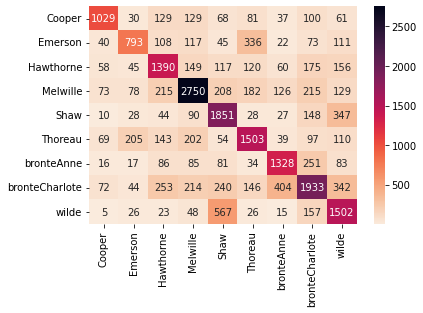

In [ ]:
conf_mat = sklearn.metrics.confusion_matrix(y_test, y_pred)
seaborn.heatmap(conf_mat,
                annot=True,
                fmt="d",
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_,
                cmap="rocket_r")
plt.show()